# Supplemental - Autorouting Quick Iteration

Use this after Notebook 05 when you want the shortest rerun loop for route candidates.

1. Define the scene and route request.
2. Run autorouting and Code_Aster study handoff.
3. Inspect candidate routes and the accepted model in interactive 3D.
4. Export/share the interactive HTML scene.

`RUN_CODE_ASTER = False` keeps the notebook portable by exporting candidate studies without executing the solver. Set it to `True` only when the configured Code_Aster runtime is available; exported studies are not completed engineering evaluations until Code_Aster has run and result artifacts have been imported.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tuba import Model
from tuba.analysis.code_aster_notebook import configure_code_aster_notebook_runtime
from tuba.routing import AutoroutingAgent, GridRouter
from tuba.routing.solver_loop import SolverLoopConfig
from tuba.routing.types import PipeRouteRequest, RouteEndpoint, RoutingConstraints, RoutingGridSpec
from tuba.routing.visualization import build_route_plotter, export_route_scene_html

import pyvista as pv

# Defaults to zoomable embedded HTML. Use TUBA_NOTEBOOK_BACKEND=client or trame for server/client mode.
from tuba.plotting.notebook import configure_notebook_backend
JUPYTER_BACKEND = configure_notebook_backend()

OUTPUT_ROOT = REPO_ROOT / "routing_reports" / "notebook_demo"
OUTPUT_ROOT

WindowsPath('D:/Gitprojects/Tuba_v4/routing_reports/notebook_demo')

## 1. Define the Scene

The scene is a normal `TubaModel`. Obstacles are currently easiest to define as cuboid keepout volumes. Existing pipe elements in the model can also be treated as obstacles for later routed pipes.

In [2]:
def build_scene() -> Model:
    model = Model("NotebookAutoroutingDemo")
    model.add_material(
        "steel",
        E=210e9,
        nu=0.3,
        rho=7850,
        alpha=12e-6,
        allowable_stress={20.0: 140e6, 120.0: 125e6},
    )
    model.add_pipe_section("DN100", OD=0.1143, WT=0.00602)
    model.define_load_case("Hot", gravity=True, pressure=1.0e6, temperature=120.0)

    model.add_obstacle(
        id="equipment_box",
        type="cuboid",
        min_point=[1.5, -0.4, -0.4],
        max_point=[2.5, 0.4, 0.4],
    )
    model.add_obstacle(
        id="maintenance_keepout",
        type="cuboid",
        min_point=[2.8, 0.8, -0.4],
        max_point=[3.4, 1.4, 0.8],
    )
    return model


model = build_scene()
model.obstacles

[{'id': 'equipment_box',
  'type': 'cuboid',
  'min_point': [1.5, -0.4, -0.4],
  'max_point': [2.5, 0.4, 0.4]},
 {'id': 'maintenance_keepout',
  'type': 'cuboid',
  'min_point': [2.8, 0.8, -0.4],
  'max_point': [3.4, 1.4, 0.8]}]

## 2. Define the Route Request

`PipeRouteRequest` defines from which endpoint to which endpoint the router should work. The optional endpoint directions constrain the first/last pipe legs. The constraints define clearance, insulation, bend feasibility, and whether to avoid obstacles/existing pipes.

In [3]:
request = PipeRouteRequest(
    id="P-100",
    start=RouteEndpoint(
        id="pump_nozzle",
        point=(0.0, 0.0, 0.0),
        direction=None,
        min_straight=0.0,
    ),
    goal=RouteEndpoint(
        id="rack_tie_in",
        point=(4.0, 0.0, 0.0),
        direction=None,
        min_straight=0.0,
    ),
    section="DN100",
    material="steel",
    constraints=RoutingConstraints(
        clearance=0.10,
        insulation_thickness=0.03,
        min_bend_radius=0.20,
        avoid_existing_pipes=True,
        avoid_obstacles=True,
    ),
)

request

PipeRouteRequest(id='P-100', start=RouteEndpoint(id='pump_nozzle', point=(0.0, 0.0, 0.0), direction=None, min_straight=0.0), goal=RouteEndpoint(id='rack_tie_in', point=(4.0, 0.0, 0.0), direction=None, min_straight=0.0), section='DN100', material='steel', constraints=RoutingConstraints(clearance=0.1, insulation_thickness=0.03, min_bend_radius=0.2, min_straight_between_bends=0.0, max_bends=None, max_length=None, slope=None, slope_axis=None, avoid_existing_pipes=True, avoid_obstacles=True, allowed_directions=None), costs=RoutingCostWeights(length=1.0, bend=5.0, vertical=1.0, clearance=0.0, support_span=0.5, rack_preference=0.0, direction_change=0.0), preferred_waypoints=(), forbidden_zones=(), preferred_zones=(), routing_space=None, thermal_requirements=None, solver_acceptance=None, metadata={})

## 3. Run Autorouting and Code_Aster Study Handoff

This cell routes candidates, exports Code_Aster study files, applies the selected route to the model, and writes Markdown/JSON reports. Keep `RUN_CODE_ASTER = False` unless the configured Code_Aster runtime is available.


In [4]:
CODE_ASTER_RUNTIME = configure_code_aster_notebook_runtime()
RUN_CODE_ASTER = False

model = build_scene()
agent = AutoroutingAgent(
    router=GridRouter(
        RoutingGridSpec(cell_size=0.25, margin=1.0, allow_diagonal=False),
        candidate_count=4,
    ),
    solver_config=SolverLoopConfig(
        run_solver=RUN_CODE_ASTER,
        export_study=True,
        exec_method=CODE_ASTER_RUNTIME.exec_method,
        wsl_distro=CODE_ASTER_RUNTIME.wsl_distro,
        docker_image=CODE_ASTER_RUNTIME.docker_image,
        max_solver_candidates=3,
        load_case="Hot",
        strict=RUN_CODE_ASTER,
    ),
    output_root=OUTPUT_ROOT,
)

run = agent.route_pipe(model, request, apply=True, add_supports=True, support_spacing=2.0)
result = run.result
selected = result.selected

print(f"Selected candidate: {result.selected_index}")
print(f"Created elements: {run.created_element_ids}")
print(f"Report: {run.report_path}")
print(f"Diagnostics: {result.diagnostics}")
selected.points if selected else None

Selected candidate: 0
Created elements: ['pipe_str_0', 'pipe_bend_0', 'pipe_str_1', 'pipe_str_2', 'pipe_bend_1', 'pipe_str_3']
Report: D:\Gitprojects\Tuba_v4\routing_reports\notebook_demo\P-100\route_report.md
Diagnostics: []


[(0.0, 0.0, 0.0), (0.0, 0.0, 0.75), (4.0, 0.0, 0.75), (4.0, 0.0, 0.0)]

## 4. Interactive Candidate Results

Selected candidate is shown with a thicker green pipe. Other candidates are translucent colored pipes. Obstacles remain visible for route review.


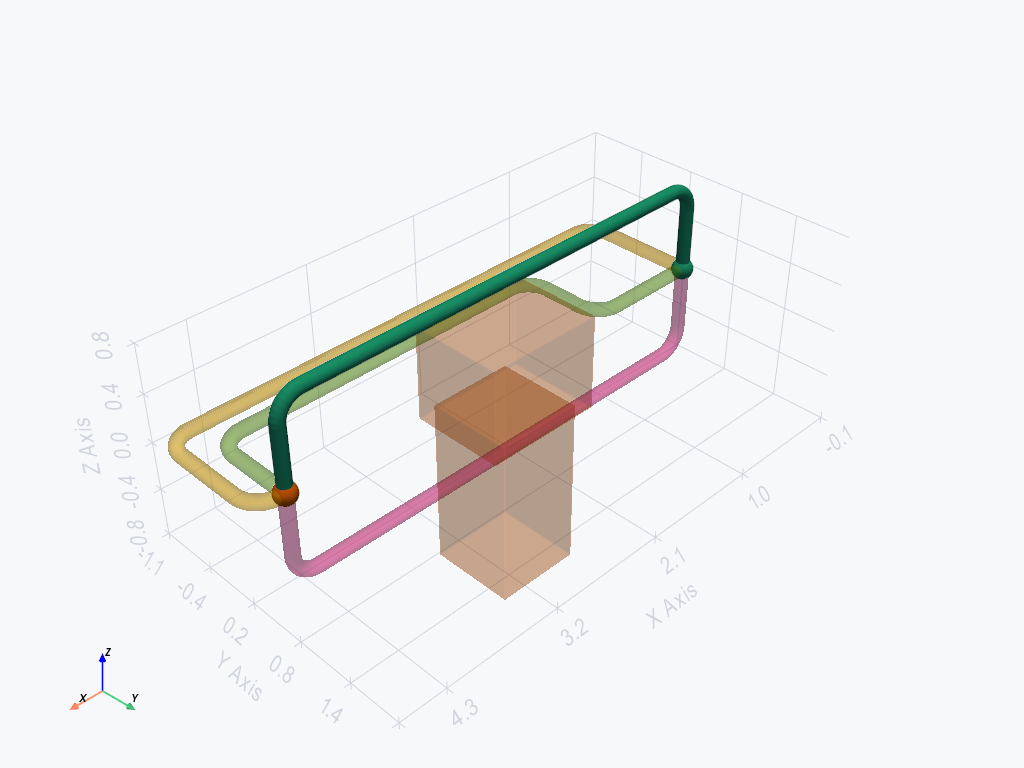

In [5]:
candidate_scene = build_route_plotter(model, request=request, result=result, show_existing_model=False)
candidate_scene.show(jupyter_backend=JUPYTER_BACKEND)

## 5. Interactive Accepted Model

Because the run used `apply=True`, the selected route was converted to actual `TubaModel` pipe elements. This scene shows the accepted model geometry.


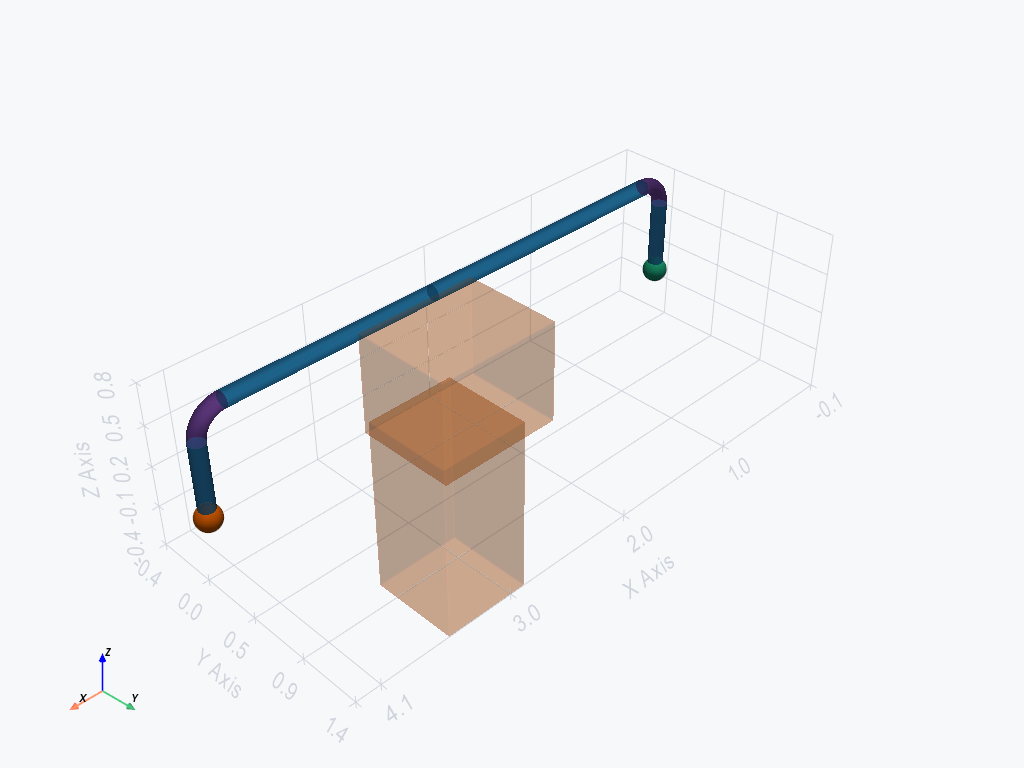

In [6]:
accepted_scene = build_route_plotter(model, request=request, show_existing_model=True)
accepted_scene.show(jupyter_backend=JUPYTER_BACKEND)

## 6. Export Interactive HTML Scene

This writes a standalone interactive HTML scene for browser review. PyVista requires Trame for `export_html()`.


In [7]:
html_path = OUTPUT_ROOT / request.id / "route_scene.html"
try:
    exported = export_route_scene_html(model, html_path, request=request, result=result)
    print(f"Interactive HTML scene: {exported}")
except Exception as exc:
    print("HTML export unavailable:", exc)
    print("Install: python -m pip install -e '.[notebook-viz]'")

Interactive HTML scene: D:\Gitprojects\Tuba_v4\routing_reports\notebook_demo\P-100\route_scene.html


## Optional: Scene Before Routing

Use this only when you want to inspect endpoints and keepout volumes before generating candidates. The faster path is to run the autorouting cell first and inspect the candidate scene.


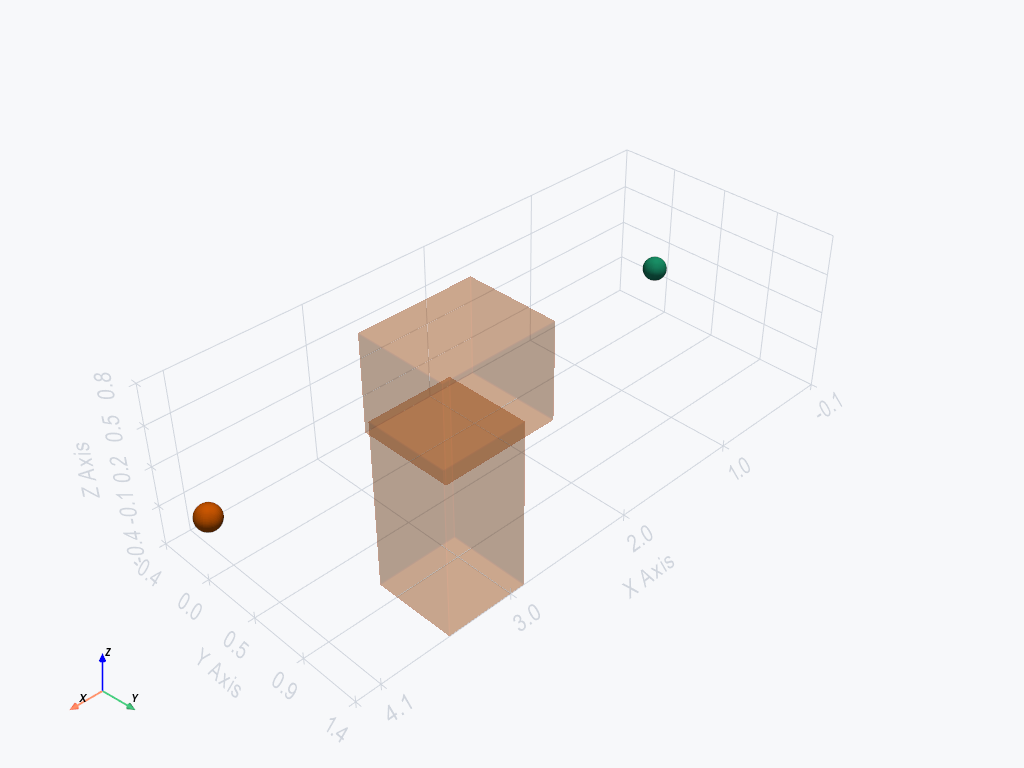

In [8]:
pre_route_model = build_scene()
scene_before = build_route_plotter(pre_route_model, request=request)
scene_before.show(jupyter_backend=JUPYTER_BACKEND)


## Candidate Table

Use this for quick comparison of cost, bend count, support span, and solver/compliance status.


In [9]:
candidate_rows = []
for idx, candidate in enumerate(result.candidates):
    solver = candidate.metadata.get("solver", {})
    compliance = candidate.metadata.get("compliance", {})
    candidate_rows.append(
        {
            "idx": idx,
            "selected": idx == result.selected_index,
            "valid": candidate.is_valid,
            "cost": round(candidate.cost, 3),
            "length": round(candidate.cost_breakdown.get("length", 0.0), 3),
            "bends": int(candidate.cost_breakdown.get("bends", 0.0)),
            "max_span": round(candidate.cost_breakdown.get("support_span_max", 0.0), 3),
            "solver_ran": solver.get("solver_ran", False),
            "asme_pass": compliance.get("overall_pass", "not run"),
            "diagnostics": "; ".join(candidate.diagnostics),
        }
    )

candidate_rows

[{'idx': 0,
  'selected': True,
  'valid': True,
  'cost': 19.0,
  'length': 5.5,
  'bends': 2,
  'max_span': 4.0,
  'solver_ran': False,
  'asme_pass': 'not run',
  'diagnostics': ''},
 {'idx': 1,
  'selected': False,
  'valid': True,
  'cost': 19.0,
  'length': 5.5,
  'bends': 2,
  'max_span': 4.0,
  'solver_ran': False,
  'asme_pass': 'not run',
  'diagnostics': ''},
 {'idx': 2,
  'selected': False,
  'valid': True,
  'cost': 22.0,
  'length': 5.5,
  'bends': 3,
  'max_span': 3.0,
  'solver_ran': False,
  'asme_pass': 'not run',
  'diagnostics': ''},
 {'idx': 3,
  'selected': False,
  'valid': True,
  'cost': 23.625,
  'length': 6.5,
  'bends': 3,
  'max_span': 4.25,
  'solver_ran': False,
  'asme_pass': 'not run',
  'diagnostics': ''}]

## Generated Report and Study Files


In [10]:
print(run.report_path.read_text(encoding="utf-8"))

study_files = sorted(str(path.relative_to(REPO_ROOT)) for path in OUTPUT_ROOT.rglob("study.*"))
study_files

# Route Report: P-100

## Inputs

- Start: `pump_nozzle` (0.0, 0.0, 0.0)
- Goal: `rack_tie_in` (4.0, 0.0, 0.0)
- Section: `DN100`
- Material: `steel`
- Clearance: `0.1`
- Insulation thickness: `0.03`
- Minimum bend radius: `0.2`

## Candidate Comparison

| Candidate | Valid | Cost | Length | Bends | Diagnostics |
|---:|:---:|---:|---:|---:|---|
| 0 | yes | 19.000 | 5.500 | 2 |  |
| 1 | yes | 19.000 | 5.500 | 2 |  |
| 2 | yes | 22.000 | 5.500 | 3 |  |
| 3 | yes | 23.625 | 6.500 | 3 |  |

## Selected Route

- Points: `[(0.0, 0.0, 0.0), (0.0, 0.0, 0.75), (4.0, 0.0, 0.75), (4.0, 0.0, 0.0)]`
- Cost: `19.000`
- Length: `5.500`
- Bends: `2`
- Low / high elevation: `0.000` / `0.750`
- Clash status: `no candidate diagnostics`

## Support Spans

- Maximum straight span: `4.000`
- Span count: `3`

## Solver / Compliance

- Solver ran: `False`
- Study directory: `D:\Gitprojects\Tuba_v4\routing_reports\notebook_demo\P-100\studies\P-100\candidate_0`
- ASME compliance: `not run`

## Known Limitations

['routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_0\\study.comm',
 'routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_0\\study.export',
 'routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_0\\study.mail',
 'routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_1\\study.comm',
 'routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_1\\study.export',
 'routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_1\\study.mail',
 'routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_2\\study.comm',
 'routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_2\\study.export',
 'routing_reports\\notebook_demo\\P-100\\studies\\P-100\\candidate_2\\study.mail']

## JSON Result for Regression or Agent Workflows


In [11]:
json_path = run.report_path.parent / "route_result.json"
route_data = json.loads(json_path.read_text(encoding="utf-8"))
route_data.keys(), len(route_data["candidates"])

(dict_keys(['request', 'candidates', 'selected_index', 'diagnostics']), 4)

## Viewer Notes

- **Notebook quick-look:** PyVista + the shared `JUPYTER_BACKEND` setting.
- **Shareable review:** `export_route_scene_html(...)` for the standalone route scene. Use the Tuba web-scene bundle path only when a notebook needs the reviewable `viewer/` contract.